# Medicine Recomendation Model

In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("/content/medicine.csv")

In [3]:
data.head()

,index,Drug_Name,Reason,Description
0,1,A CN Gel(Topical) 20gmA CN Soap 75gm,Acne,Mild to moderate acne (spots)
1,2,A Ret 0.05% Gel 20gmA Ret 0.1% Gel 20gmA Ret 0...,Acne,A RET 0.025% is a prescription medicine that i...
2,3,ACGEL CL NANO Gel 15gm,Acne,It is used to treat acne vulgaris in people 12...
3,4,ACGEL NANO Gel 15gm,Acne,It is used to treat acne vulgaris in people 12...
4,5,Acleen 1% Lotion 25ml,Acne,treat the most severe form of acne (nodular ac...


In [4]:
# Basic info and missing values
print("--- Dataset Info ---")
print(data.info())

print("\n--- Missing Values ---")
print(data.isnull().sum())

print("\n--- Duplicate Rows ---")
print(f"Total duplicates: {data.duplicated().sum()}")

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9720 entries, 0 to 9719
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   index        9720 non-null   int64 
 1   Drug_Name    9720 non-null   object
 2   Reason       9720 non-null   object
 3   Description  9720 non-null   object
dtypes: int64(1), object(3)
memory usage: 303.9+ KB
None

--- Missing Values ---
index          0
Drug_Name      0
Reason         0
Description    0
dtype: int64

--- Duplicate Rows ---
Total duplicates: 0


/tmp/ipykernel_2667/1656959094.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='Reason', data=data, order=data['Reason'].value_counts().index[:10], palette='viridis')


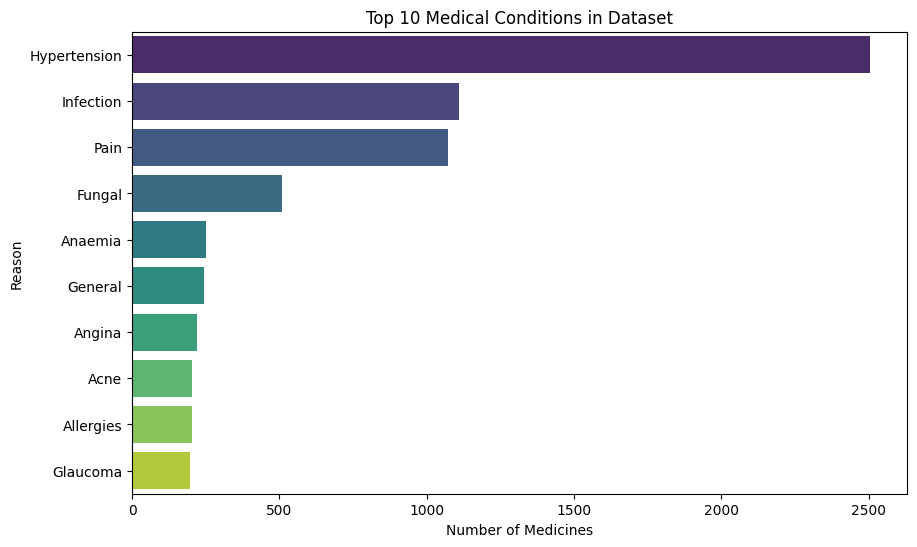

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 10 most common reasons/conditions
plt.figure(figsize=(10, 6))
sns.countplot(y='Reason', data=data, order=data['Reason'].value_counts().index[:10], palette='viridis')
plt.title('Top 10 Medical Conditions in Dataset')
plt.xlabel('Number of Medicines')
plt.show()

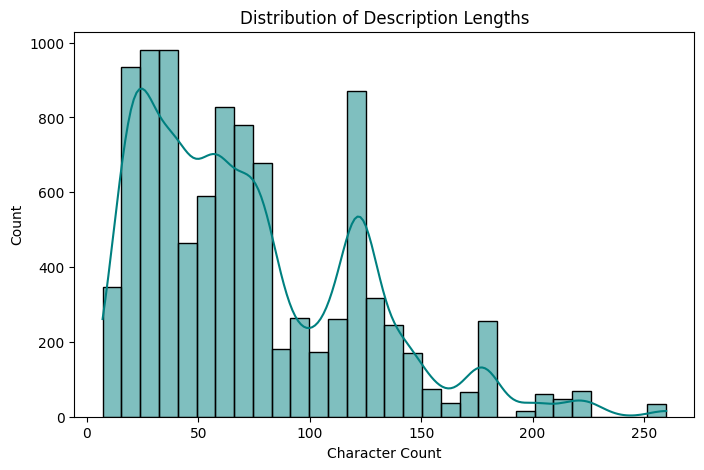

In [6]:
# Calculate description lengths
data['desc_len'] = data['Description'].astype(str).apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data['desc_len'], bins=30, kde=True, color='teal')
plt.title('Distribution of Description Lengths')
plt.xlabel('Character Count')
plt.show()

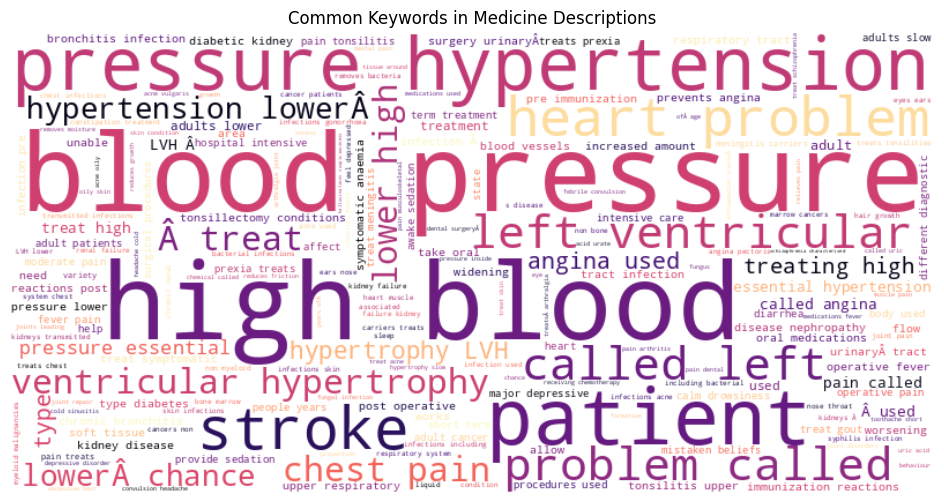

In [7]:
from wordcloud import WordCloud

# Combine all descriptions into one string
text = " ".join(desc for desc in data.Description.astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='magma').generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Common Keywords in Medicine Descriptions')
plt.show()

In [8]:
data.shape

(9720, 5)

In [9]:
data.dropna(inplace=True)

In [10]:
data.duplicated().sum()

np.int64(0)

In [11]:
data.describe()

,index,desc_len
count,9720.000000,9720.000000
mean,4860.500000,73.497016
std,2806.066642,48.760169
min,1.000000,7.000000
25%,2430.750000,34.000000
50%,4860.500000,60.000000
75%,7290.250000,109.000000
max,9720.000000,260.000000


In [12]:
data['Description']

,Description
0,Mild to moderate acne (spots)
1,A RET 0.025% is a prescription medicine that i...
2,It is used to treat acne vulgaris in people 12...
3,It is used to treat acne vulgaris in people 12...
4,treat the most severe form of acne (nodular ac...
...,...
9715,used for treating warts
9716,used to soften the skin cells
9717,used for scars
9718,used for wounds


In [13]:
data['Description'].apply(lambda x : x.split())

,Description
0,"[Mild, to, moderate, acne, (spots)]"
1,"[A, RET, 0.025%, is, a, prescription, medicine..."
2,"[It, is, used, to, treat, acne, vulgaris, in, ..."
3,"[It, is, used, to, treat, acne, vulgaris, in, ..."
4,"[treat, the, most, severe, form, of, acne, (no..."
...,...
9715,"[used, for, treating, warts]"
9716,"[used, to, soften, the, skin, cells]"
9717,"[used, for, scars]"
9718,"[used, for, wounds]"


In [14]:
data['Description'] = data['Description'].apply(lambda x : x.split())
data['Reason'] = data['Reason'].apply(lambda x : x.split())

In [15]:
data.tail()

,index,Drug_Name,Reason,Description,desc_len
9715,9716,T Muce Ointment 5gm,[Wound],"[used, for, treating, warts]",23
9716,9717,Wokadine 10% Solution 100mlWokadine Solution 5...,[Wound],"[used, to, soften, the, skin, cells]",29
9717,9718,Wokadine M Onit 10gm,[Wound],"[used, for, scars]",14
9718,9719,Wound Fix Solution 100ml,[Wound],"[used, for, wounds]",15
9719,9720,Wounsol Ointment 15gm,[Wound],"[used, to, treat, and, remove, raised, warts, ...",116


In [16]:
data['Description'] = data['Description'].apply(lambda x : [i.replace(" ", "") for i in x])

In [17]:
data['tags'] = data['Description'] + data['Reason']

In [18]:
data.head()

,index,Drug_Name,Reason,Description,desc_len,tags
0,1,A CN Gel(Topical) 20gmA CN Soap 75gm,[Acne],"[Mild, to, moderate, acne, (spots)]",29,"[Mild, to, moderate, acne, (spots), Acne]"
1,2,A Ret 0.05% Gel 20gmA Ret 0.1% Gel 20gmA Ret 0...,[Acne],"[A, RET, 0.025%, is, a, prescription, medicine...",76,"[A, RET, 0.025%, is, a, prescription, medicine..."
2,3,ACGEL CL NANO Gel 15gm,[Acne],"[It, is, used, to, treat, acne, vulgaris, in, ...",156,"[It, is, used, to, treat, acne, vulgaris, in, ..."
3,4,ACGEL NANO Gel 15gm,[Acne],"[It, is, used, to, treat, acne, vulgaris, in, ...",156,"[It, is, used, to, treat, acne, vulgaris, in, ..."
4,5,Acleen 1% Lotion 25ml,[Acne],"[treat, the, most, severe, form, of, acne, (no...",51,"[treat, the, most, severe, form, of, acne, (no..."


In [22]:
new_data = data[['index', 'Drug_Name', 'tags']].copy()

In [23]:
new_data.head()

,index,Drug_Name,tags
0,1,A CN Gel(Topical) 20gmA CN Soap 75gm,"[Mild, to, moderate, acne, (spots), Acne]"
1,2,A Ret 0.05% Gel 20gmA Ret 0.1% Gel 20gmA Ret 0...,"[A, RET, 0.025%, is, a, prescription, medicine..."
2,3,ACGEL CL NANO Gel 15gm,"[It, is, used, to, treat, acne, vulgaris, in, ..."
3,4,ACGEL NANO Gel 15gm,"[It, is, used, to, treat, acne, vulgaris, in, ..."
4,5,Acleen 1% Lotion 25ml,"[treat, the, most, severe, form, of, acne, (no..."


In [24]:
new_data['tags'] = new_data['tags'].apply(lambda x : " ".join(x))

In [25]:
new_data['tags'] = new_data['tags'].apply(lambda x : x.lower())

In [26]:
new_data.head()

,index,Drug_Name,tags
0,1,A CN Gel(Topical) 20gmA CN Soap 75gm,mild to moderate acne (spots) acne
1,2,A Ret 0.05% Gel 20gmA Ret 0.1% Gel 20gmA Ret 0...,a ret 0.025% is a prescription medicine that i...
2,3,ACGEL CL NANO Gel 15gm,it is used to treat acne vulgaris in people 12...
3,4,ACGEL NANO Gel 15gm,it is used to treat acne vulgaris in people 12...
4,5,Acleen 1% Lotion 25ml,treat the most severe form of acne (nodular ac...


In [27]:
new_data.to_csv('new_data.csv', index=False)
print('new_data.csv has been saved.')

new_data.csv has been saved.


In [28]:
import nltk
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(stop_words = "english", max_features = 5000)

In [30]:
def stem(text):
    y = []
    for i in text.split():
        y.append(ps.stem(i))
    return " ".join(y)

In [31]:
stem("I feel so dizzyiness")

'i feel so dizzyi'

In [32]:
new_data['tags'] = new_data['tags'].apply(stem)

In [33]:
new_data.head()

,index,Drug_Name,tags
0,1,A CN Gel(Topical) 20gmA CN Soap 75gm,mild to moder acn (spots) acn
1,2,A Ret 0.05% Gel 20gmA Ret 0.1% Gel 20gmA Ret 0...,a ret 0.025% is a prescript medicin that is us...
2,3,ACGEL CL NANO Gel 15gm,it is use to treat acn vulgari in peopl 12 yea...
3,4,ACGEL NANO Gel 15gm,it is use to treat acn vulgari in peopl 12 yea...
4,5,Acleen 1% Lotion 25ml,treat the most sever form of acn (nodular acne...


In [35]:
vectors = cv.fit_transform(new_data['tags']).toarray()

In [36]:
vectors.shape

(9720, 806)

In [37]:
cv.get_feature_names_out()

array(['025', '12', '16', '18', 'abdomin', 'abl', 'ach', 'acid', 'acn',
       'acne', 'acquir', 'action', 'activ', 'acut', 'acute', 'adequ',
       'adhd', 'adjunct', 'adolesc', 'adult', 'adults', 'affect', 'ag',
       'age', 'aids', 'allerg', 'allergen', 'allergi', 'allow', 'alon',
       'alzheim', 'alzheimer', 'alzheimerâ', 'amoebiasi', 'anaemia',
       'anal', 'angina', 'angl', 'ani', 'ankylos', 'anorexia', 'anoth',
       'anti', 'antioxid', 'antipsychot', 'antiretrovir', 'anxieti',
       'anxiou', 'anxious', 'apnoea', 'appear', 'appetit', 'appetite',
       'appli', 'appropri', 'area', 'arrhythmia', 'arrhythmiasi',
       'arteri', 'arthralgia', 'arthriti', 'associ', 'atherothrombot',
       'athleteâ', 'atop', 'atrial', 'attack', 'awak', 'b1', 'b2', 'b3',
       'b5', 'b6', 'babi', 'backache', 'bacteri', 'bacteria', 'balanc',
       'balanitis', 'bandag', 'becom', 'behaviour', 'beliefs', 'benefit',
       'beta', 'biliari', 'biotin', 'bite', 'blackhead', 'blackheads',
      

In [38]:
from sklearn.metrics.pairwise import cosine_similarity

In [39]:
similarity = cosine_similarity(vectors)

In [40]:
similarity[1]

array([0.25197632, 1.        , 0.25660012, ..., 0.19245009, 0.1490712 ,
       0.0860663 ])

In [45]:
def recommend(medicine):
    try:
        # 1. Get the index of the medicine
        medicine_index = new_data[new_data['Drug_Name'] == medicine].index[0]

        # 2. Get the row of similarity scores
        distances = similarity[medicine_index]

        # 3. Sort them: higher score = more similar
        # list(enumerate()) keeps the index so we can look up the drug name later
        medicine_list = sorted(list(enumerate(distances)), reverse=True, key=lambda x: x[1])[1:6]

        print(f"Recommendations for '{medicine}':")
        for i in medicine_list:
            print(f"- {new_data.iloc[i[0]].Drug_Name}")

    except IndexError:
        print("Medicine not found. Please check the spelling!")

# Test it
recommend("ACGEL CL NANO Gel 15gm")

Recommendations for 'ACGEL CL NANO Gel 15gm':
- ACGEL NANO Gel 15gm
- Acnehit Gel 15gm
- Acnelak Soap 75gm
- Acnetor AD 1% Ointment 15gm
- Acnetor AD Cream 15Acnetor AD Gel 15gm


In [47]:
import pickle

# Save the DataFrame (usually small, no issues here)
with open('medicine_dict.pkl', 'wb') as f:
    pickle.dump(new_data.to_dict(), f)

# Convert similarity matrix to float16 to save MASSIVE space
# This changes a ~800MB file into a ~200MB file
similarity_compressed = similarity.astype('float16')

with open('model.pkl', 'wb') as f:
    pickle.dump(similarity_compressed, f)